# ⚙️ Proyecto: Optimización de Hiperparámetros

## Datos del alumno

| Campo | Completar |
|---|---|
| **Nombre y apellido** | *(Juan Bautista Leon Dimidjian)* |
| **Dataset elegido** | *(Iris)* |
| **Fuente / URL** | *(https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)* |
| **Variable objetivo (target)** | *(especies de la flor)* |
| **Tipo de problema** | *(multiclase)* |

---

## ¿Qué vas a construir?

Vas a explorar sistemáticamente **cómo distintas configuraciones afectan el rendimiento de una red neuronal**. El objetivo no es solo obtener un buen resultado, sino entender *por qué* unas configuraciones funcionan mejor que otras.

**Hiperparámetros que vas a explorar:**
- Learning rate
- Número de capas y neuronas
- Tasa de Dropout
- Batch size
- Búsqueda automática con Keras Tuner

---
> ⚠️ **Estructura del cuaderno:** primero vas a armar un modelo base, luego hacer Grid Search manual, luego Keras Tuner automático, y finalmente comparar los tres. Las celdas con `# 🔧 TU CÓDIGO` son las que tenés que completar.

---
## Paso 1 — Instalación e importaciones

**¿Qué hace este paso?**  
Instala `keras-tuner`, la librería de Keras para búsqueda automática de hiperparámetros. Es la herramienta central de este cuaderno.

In [4]:
!pip install -q scikit-learn tensorflow keras-tuner matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

print(f'TensorFlow: {tf.__version__}')
print(f'Keras Tuner: {kt.__version__}')
print('✅ Listo')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.3 MB/s eta 0:00:00
TensorFlow: 2.20.0
Keras Tuner: 1.4.8
✅ Listo


---
## Paso 2 — Carga y exploración del dataset

**¿Qué hace este paso?**  
Cargamos el dataset. Para optimización, es ideal usar datasets de tamaño mediano (500–20k filas): con pocos datos las diferencias entre configuraciones son ruidosas; con demasiados, el tiempo de búsqueda es prohibitivo en Colab.

**🔧 Tu tarea:** cargá tu dataset y definí la columna objetivo.

In [5]:
# 🔧 TU CÓDIGO: cargá el dataset
from sklearn.datasets import load_iris
import pandas as pd  # <-- Agregamos esto para solucionar el NameError

# Cargamos el objeto iris
iris = load_iris()

# Creamos el DataFrame con las características (features)
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)

# Añadimos la columna objetivo (target)
df['target'] = iris.target

# 🔧 Nombre de la columna objetivo
TARGET_COL = 'target'

# 🔧 Tipo de problema: 'regression', 'binary', 'multiclass'
PROBLEM_TYPE = 'multiclass'  # <-- Cambiado de 'regression' a 'multiclass'

print(f'Shape: {df.shape}')
print(f'Target: {TARGET_COL}')
print(f'Tipo: {PROBLEM_TYPE}')
df.describe()

Shape: (150, 5)
Target: target
Tipo: multiclass


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


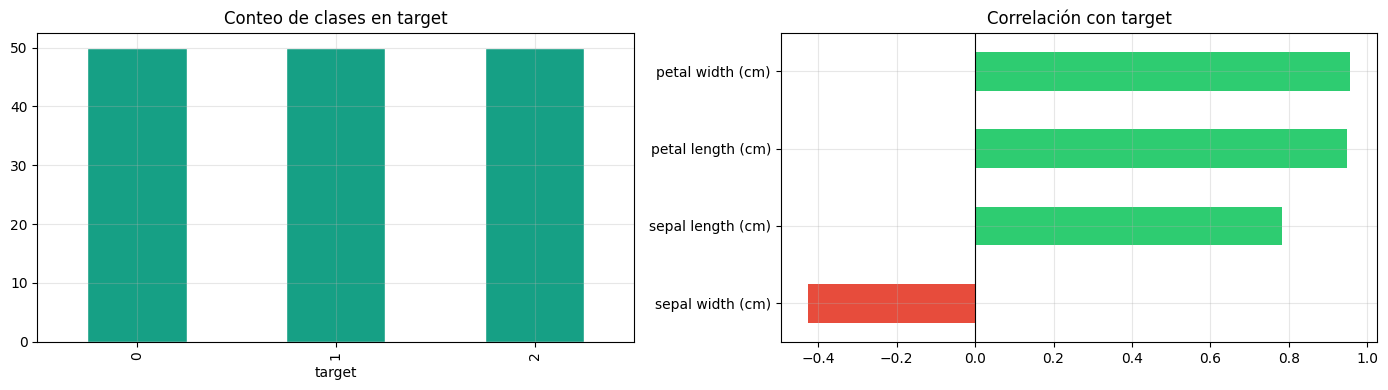

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución del target
if PROBLEM_TYPE == 'regression':
    axes[0].hist(df[TARGET_COL], bins=40, color='#16a085', edgecolor='white')
    axes[0].set_title(f'Distribución de {TARGET_COL}')
else:
    df[TARGET_COL].value_counts().plot(kind='bar', ax=axes[0], color='#16a085', edgecolor='white')
    axes[0].set_title(f'Conteo de clases en {TARGET_COL}')
axes[0].grid(True, alpha=0.3)

# Correlación con el target (solo para columnas numéricas)
corr_vals = df.corr()[TARGET_COL].drop(TARGET_COL).sort_values()
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in corr_vals]
corr_vals.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title(f'Correlación con {TARGET_COL}')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📝 Análisis del dataset — completar

1. **¿Qué tamaño tiene el dataset?** ¿Es adecuado para optimización de hiperparámetros?
   > *Escribir aquí*

2. **¿Qué features tienen mayor correlación con el target?**
   > *Escribir aquí*

---
## Paso 3 — Preprocesamiento

**¿Qué hace este paso?**  
Prepara los datos para el entrenamiento. También configuramos automáticamente la capa de salida y la función de pérdida según el tipo de problema.

In [7]:
# 🔧 Tratá valores nulos si los hay
# df.dropna(inplace=True)
# df = pd.get_dummies(df, drop_first=True)  # para variables categóricas

X = df.drop(TARGET_COL, axis=1).values
y = df[TARGET_COL].values

if PROBLEM_TYPE != 'regression':
    from sklearn.preprocessing import LabelEncoder
    y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Configuración automática según tipo de problema
N_FEATURES = X_train_s.shape[1]
N_CLASES   = len(np.unique(y))

if PROBLEM_TYPE == 'regression':
    OUTPUT_UNITS      = 1
    OUTPUT_ACTIVATION = 'linear'
    LOSS              = 'mse'
    MONITOR_METRIC    = 'val_mae'
    METRIC            = 'mae'
elif PROBLEM_TYPE == 'binary':
    OUTPUT_UNITS      = 1
    OUTPUT_ACTIVATION = 'sigmoid'
    LOSS              = 'binary_crossentropy'
    MONITOR_METRIC    = 'val_accuracy'
    METRIC            = 'accuracy'
else:  # multiclass
    OUTPUT_UNITS      = N_CLASES
    OUTPUT_ACTIVATION = 'softmax'
    LOSS              = 'sparse_categorical_crossentropy'
    MONITOR_METRIC    = 'val_accuracy'
    METRIC            = 'accuracy'

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')
print(f'Configuración → Loss: {LOSS} | Salida: {OUTPUT_UNITS} × {OUTPUT_ACTIVATION}')

Train: (120, 4) | Test: (30, 4)
Configuración → Loss: sparse_categorical_crossentropy | Salida: 3 × softmax


---
## Paso 4 — Función de evaluación y modelo base

**¿Qué hace este paso?**  
Definimos una función reutilizable `evaluate_model()` que encapsula el ciclo de entrenamiento y evaluación. Así garantizamos que todos los experimentos se comparan en las mismas condiciones.

Luego entrenamos el **modelo base**: una arquitectura simple, elegida sin ningún proceso de optimización. Es el punto de partida contra el cual mediremos toda mejora.

In [8]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te,
                   epochs=80, batch_size=64, verbose=0):
    """Entrena y evalúa, retorna diccionario con métricas y history."""
    cb = [keras.callbacks.EarlyStopping(
        monitor=MONITOR_METRIC, patience=12, restore_best_weights=True,
        mode='min' if PROBLEM_TYPE == 'regression' else 'max'
    )]
    history = model.fit(
        X_tr, y_tr,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.15,
        callbacks=cb,
        verbose=verbose
    )
    y_pred_raw = model.predict(X_te, verbose=0)

    if PROBLEM_TYPE == 'regression':
        y_pred = y_pred_raw.flatten()
        return {
            'mae':  mean_absolute_error(y_te, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_te, y_pred)),
            'r2':   r2_score(y_te, y_pred),
            'history': history
        }
    else:
        y_pred = (y_pred_raw.flatten() >= 0.5).astype(int) if PROBLEM_TYPE == 'binary' \
                 else np.argmax(y_pred_raw, axis=1)
        return {
            'accuracy': accuracy_score(y_te, y_pred),
            'history': history
        }

def build_base_model():
    m = keras.Sequential([
        layers.Input(shape=(N_FEATURES,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(OUTPUT_UNITS, activation=OUTPUT_ACTIVATION)
    ])
    m.compile(optimizer='adam', loss=LOSS, metrics=[METRIC])
    return m

tf.random.set_seed(42)
base_model  = build_base_model()
base_results = evaluate_model(base_model, X_train_s, y_train, X_test_s, y_test)

print('MODELO BASE (sin optimización):')
for k, v in base_results.items():
    if k != 'history':
        print(f'  {k.upper()}: {v:.4f}')

MODELO BASE (sin optimización):
  ACCURACY: 0.7000


### 📝 Modelo base — completar

1. **¿Cuál es el rendimiento del modelo base?** ¿Te parece un buen punto de partida?
   > *Escribir aquí*

2. **¿Creés que hay margen de mejora mediante optimización?** ¿Por qué?
   > *Escribir aquí*

---
## Paso 5 — Grid Search manual

**¿Qué hace este paso?**  
Probamos exhaustivamente todas las combinaciones de un conjunto **manual y predefinido** de hiperparámetros.

**Ventaja:** simple de implementar, fácil de interpretar.  
**Limitación:** el número de experimentos crece exponencialmente. Con 3 valores por 3 hiperparámetros = 27 combinaciones. Con 5 hiperparámetros = cientos de experimentos.

**🔧 Tu tarea:** ajustá los valores de la grilla según tu dataset y el tiempo disponible en Colab.

In [13]:
# 🔧 Definí la grilla de hiperparámetros a explorar
# Recomendación: no más de 3 valores por hiperparámetro para que no tarde demasiado
learning_rates = [0.01, 0.001, 0.0001]        # 🔧 ajustar
layer_configs  = [(64, 32), (32, 16), (128, 64)]  # 🔧 ajustar

grid_results = []
total = len(learning_rates) * len(layer_configs)
print(f'Total de combinaciones a probar: {total}')
print('Explorando...')

for i, (lr, (l1, l2)) in enumerate(product(learning_rates, layer_configs), 1):
    tf.random.set_seed(42)
    m = keras.Sequential([
        layers.Input(shape=(N_FEATURES,)),
        layers.Dense(l1, activation='relu'),
        layers.Dense(l2, activation='relu'),
        layers.Dense(OUTPUT_UNITS, activation=OUTPUT_ACTIVATION)
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=LOSS, metrics=[METRIC]
    )
    res = evaluate_model(m, X_train_s, y_train, X_test_s, y_test)

    row = {'lr': lr, 'l1': l1, 'l2': l2}
    row.update({k: v for k, v in res.items() if k != 'history'})
    grid_results.append(row)

    metric_key = 'r2' if PROBLEM_TYPE == 'regression' else 'accuracy'
    print(f'  [{i}/{total}] lr={lr} | capas=({l1},{l2}) → {metric_key.upper()}={res[metric_key]:.4f}')

df_grid = pd.DataFrame(grid_results).sort_values(metric_key, ascending=(PROBLEM_TYPE == 'regression'))
# Para regresión queremos menor R² en último (falso, queremos mayor); corregimos:
if PROBLEM_TYPE == 'regression':
    df_grid = df_grid.sort_values('r2', ascending=False)

print('\n✅ Grid Search completado — Mejores resultados:')
print(df_grid.to_string(index=False))

Total de combinaciones a probar: 9
Explorando...
  [1/9] lr=0.01 | capas=(64,32) → ACCURACY=1.0000
  [2/9] lr=0.01 | capas=(32,16) → ACCURACY=1.0000
  [3/9] lr=0.01 | capas=(128,64) → ACCURACY=0.9333


  [4/9] lr=0.001 | capas=(64,32) → ACCURACY=0.9000


  [5/9] lr=0.001 | capas=(32,16) → ACCURACY=0.6000
  [6/9] lr=0.001 | capas=(128,64) → ACCURACY=0.8333
  [7/9] lr=0.0001 | capas=(64,32) → ACCURACY=0.7667
  [8/9] lr=0.0001 | capas=(32,16) → ACCURACY=0.3333
  [9/9] lr=0.0001 | capas=(128,64) → ACCURACY=0.8000

✅ Grid Search completado — Mejores resultados:
    lr  l1  l2  accuracy
0.0100  64  32  1.000000
0.0100  32  16  1.000000
0.0100 128  64  0.933333
0.0010  64  32  0.900000
0.0010 128  64  0.833333
0.0001 128  64  0.800000
0.0001  64  32  0.766667
0.0010  32  16  0.600000
0.0001  32  16  0.333333


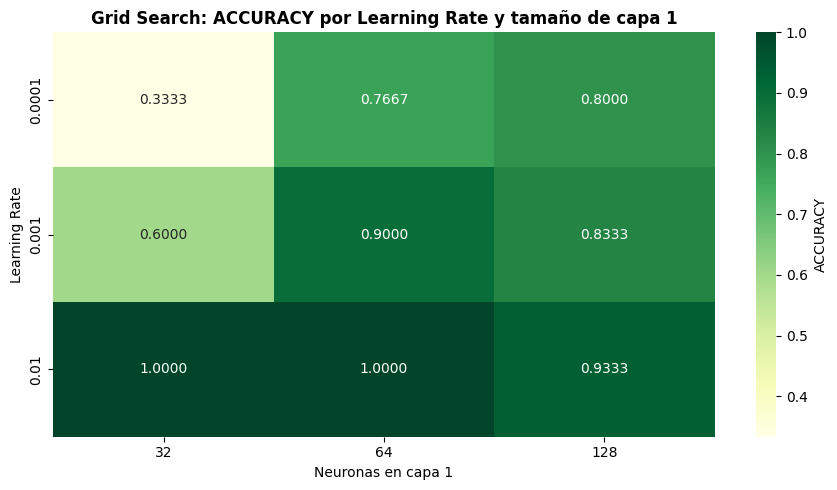


⭐ Mejor configuración del Grid Search:
   LR=0.01 | Capas=(64,32) | ACCURACY=1.0000


In [14]:
# Visualización del Grid Search como heatmap
metric_key = 'r2' if PROBLEM_TYPE == 'regression' else 'accuracy'
pivot = df_grid.pivot_table(index='lr', columns='l1', values=metric_key)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
            cbar_kws={'label': metric_key.upper()})
plt.title(f'Grid Search: {metric_key.upper()} por Learning Rate y tamaño de capa 1',
          fontweight='bold')
plt.xlabel('Neuronas en capa 1')
plt.ylabel('Learning Rate')
plt.tight_layout()
plt.show()

best_gs = df_grid.iloc[0]
print(f'\n⭐ Mejor configuración del Grid Search:')
print(f'   LR={best_gs["lr"]} | Capas=({best_gs["l1"]:.0f},{best_gs["l2"]:.0f}) | {metric_key.upper()}={best_gs[metric_key]:.4f}')

### 📝 Análisis del Grid Search — completar

1. **¿Qué learning rate resultó mejor?** ¿Era el que esperabas?
   > *Escribir aquí*

2. **¿La arquitectura más grande siempre fue mejor?** ¿Hay algún caso donde más neuronas empeoró el resultado?
   > *Escribir aquí*

3. **¿Cuánto mejoró el Grid Search respecto al modelo base?**
   > *Escribir aquí*

4. **¿Qué hiperparámetros adicionales te gustaría haber explorado pero no estaban en la grilla?**
   > *Escribir aquí*

---
## Paso 6 — Optimización automática con Keras Tuner

**¿Qué hace este paso?**  
Keras Tuner automatiza la búsqueda definiendo un **espacio de búsqueda** y usando la **Bayesian Optimization**: a diferencia del Grid Search (que prueba todo ciegamente), esta técnica aprende de los experimentos anteriores para dirigir la búsqueda hacia las zonas prometedoras del espacio.

**🔧 Tu tarea:** podés ampliar el espacio de búsqueda agregando más hiperparámetros a `build_tunable_model()`.

In [15]:
def build_tunable_model(hp):
    """Define el espacio de búsqueda de hiperparámetros para Keras Tuner."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(N_FEATURES,)))

    # 🔧 Espacio de búsqueda — podés agregar más opciones

    # Número de capas ocultas
    n_layers = hp.Int('n_layers', min_value=1, max_value=3, step=1)

    for i in range(n_layers):
        # Neuronas por capa
        units = hp.Choice(f'units_{i}', values=[16, 32, 64, 128])
        model.add(layers.Dense(units, activation='relu'))

        # ¿Usar Dropout en esta capa?
        if hp.Boolean(f'dropout_{i}'):
            rate = hp.Float(f'dropout_rate_{i}', min_value=0.1, max_value=0.4, step=0.1)
            model.add(layers.Dropout(rate))

    model.add(layers.Dense(OUTPUT_UNITS, activation=OUTPUT_ACTIVATION))

    # Learning rate continuo en escala logarítmica
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=LOSS,
        metrics=[METRIC]
    )
    return model

tuner = kt.BayesianOptimization(
    build_tunable_model,
    objective=kt.Objective(MONITOR_METRIC,
                           direction='min' if PROBLEM_TYPE == 'regression' else 'max'),
    max_trials=20,       # 🔧 aumentar para mejor resultado (pero más tiempo)
    executions_per_trial=1,
    directory='kt_search',
    project_name=f'optim_{TARGET_COL}',
    overwrite=True
)

tuner.search_space_summary()

Search space summary
Default search space size: 4
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units_0 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64, 128], 'ordered': True}
dropout_0 (Boolean)
{'default': False, 'conditions': []}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}


In [16]:
# Ejecutamos la búsqueda
stop_early = keras.callbacks.EarlyStopping(
    monitor=MONITOR_METRIC, patience=8,
    mode='min' if PROBLEM_TYPE == 'regression' else 'max'
)

print('🔍 Iniciando búsqueda automática...')
tuner.search(
    X_train_s, y_train,
    epochs=60,
    validation_split=0.15,
    callbacks=[stop_early],
    verbose=1
)

print('\n✅ Búsqueda completada')
print('\nResumen de los mejores 5 trials:')
tuner.results_summary(num_trials=5)

Trial 20 Complete [00h 00m 06s]
val_accuracy: 0.8333333134651184

Best val_accuracy So Far: 1.0
Total elapsed time: 00h 01m 38s

✅ Búsqueda completada

Resumen de los mejores 5 trials:
Results summary
Results in kt_search/optim_target
Showing 5 best trials
Objective(name="val_accuracy", direction="max")

Trial 07 summary
Hyperparameters:
n_layers: 1
units_0: 128
dropout_0: False
learning_rate: 0.00012917374266665043
dropout_rate_0: 0.4
units_1: 32
dropout_1: True
dropout_rate_1: 0.2
units_2: 64
dropout_2: False
Score: 1.0

Trial 03 summary
Hyperparameters:
n_layers: 1
units_0: 64
dropout_0: True
learning_rate: 0.007653851758014979
dropout_rate_0: 0.1
units_1: 32
dropout_1: True
Score: 0.9444444179534912

Trial 06 summary
Hyperparameters:
n_layers: 3
units_0: 64
dropout_0: False
learning_rate: 0.0046070796416100655
dropout_rate_0: 0.4
units_1: 128
dropout_1: False
dropout_rate_1: 0.4
units_2: 16
dropout_2: False
Score: 0.9444444179534912

Trial 10 summary
Hyperparameters:
n_layers: 3
un

---
## Paso 7 — Entrenamiento final del mejor modelo

**¿Qué hace este paso?**  
Tomamos la mejor configuración encontrada por Keras Tuner y entrenamos el modelo final con más épocas y callbacks más estrictos. Esta separación entre *búsqueda* (rápida) y *entrenamiento final* (exhaustivo) es una práctica estándar en ML.

In [17]:
# Mejores hiperparámetros
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print('🏆 Mejores hiperparámetros encontrados:')
for key, val in best_hp.values.items():
    print(f'   {key}: {val}')

# Entrenamiento final
tf.random.set_seed(42)
best_model = tuner.hypermodel.build(best_hp)

callbacks_final = [
    keras.callbacks.EarlyStopping(
        monitor=MONITOR_METRIC, patience=20, restore_best_weights=True,
        mode='min' if PROBLEM_TYPE == 'regression' else 'max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6
    )
]

history_best = best_model.fit(
    X_train_s, y_train,
    epochs=150,       # 🔧 ajustar si es necesario
    batch_size=64,    # 🔧 ajustar
    validation_split=0.15,
    callbacks=callbacks_final,
    verbose=1
)

print(f'\n✅ Entrenamiento finalizado en época {len(history_best.history["loss"])}')

🏆 Mejores hiperparámetros encontrados:
   n_layers: 1
   units_0: 128
   dropout_0: False
   learning_rate: 0.00012917374266665043
   dropout_rate_0: 0.4
   units_1: 32
   dropout_1: True
   dropout_rate_1: 0.2
   units_2: 64
   dropout_2: False
Epoch 1/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 235ms/step - accuracy: 0.4118 - loss: 1.0974 - val_accuracy: 0.3889 - val_loss: 1.1351 - learning_rate: 1.2917e-04
Epoch 2/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4216 - loss: 1.0909 - val_accuracy: 0.3889 - val_loss: 1.1295 - learning_rate: 1.2917e-04
Epoch 3/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.4314 - loss: 1.0844 - val_accuracy: 0.3889 - val_loss: 1.1239 - learning_rate: 1.2917e-04
Epoch 4/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.4608 - loss: 1.0780 - val_accuracy: 0.3889 - val_loss: 1.1184 - learning_rate: 1.2917e-04
Epoch 5/150
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4608 - loss: 1.0717 - val_accuracy: 0.4444 - val_loss: 1.1129 - learning_

---
## Paso 8 — Comparación final de los tres enfoques

**¿Qué hace este paso?**  
Comparamos los tres niveles de sofisticación en la búsqueda de hiperparámetros. Esto ilustra el trade-off fundamental entre esfuerzo humano, tiempo de cómputo y calidad del resultado.

In [18]:
# Métricas del mejor modelo de Keras Tuner
y_pred_best = best_model.predict(X_test_s, verbose=0)

if PROBLEM_TYPE == 'regression':
    y_pred_best = y_pred_best.flatten()
    kt_results = {
        'mae':  mean_absolute_error(y_test, y_pred_best),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred_best)),
        'r2':   r2_score(y_test, y_pred_best)
    }
    base_val = base_results.get('r2', 0)
    gs_val   = best_gs.get('r2', 0)
    kt_val   = kt_results['r2']
    metric_display = 'R²'

    print('='*55)
    print(f'{"Modelo":<15} {"MAE":>10} {"RMSE":>10} {"R²":>10}')
    print('='*55)
    for nombre, res in [('Modelo Base', base_results), ('Keras Tuner', kt_results)]:
        print(f'{nombre:<15} {res["mae"]:>10.4f} {res["rmse"]:>10.4f} {res["r2"]:>10.4f}')
    print(f'{"Grid Search":<15} {best_gs["mae"]:>10.4f} {best_gs["rmse"]:>10.4f} {best_gs["r2"]:>10.4f}')
    print('='*55)

else:
    y_pred_final = (y_pred_best.flatten() >= 0.5).astype(int) if PROBLEM_TYPE == 'binary' \
                   else np.argmax(y_pred_best, axis=1)
    kt_acc    = accuracy_score(y_test, y_pred_final)
    base_val  = base_results.get('accuracy', 0)
    gs_val    = best_gs.get('accuracy', 0)
    kt_val    = kt_acc
    metric_display = 'Accuracy'

    print('='*40)
    print(f'{"Modelo":<20} {"Accuracy":>12}')
    print('='*40)
    print(f'{"Modelo Base":<20} {base_val:>12.4f}')
    print(f'{"Grid Search":<20} {gs_val:>12.4f}')
    print(f'{"Keras Tuner":<20} {kt_val:>12.4f}')
    print('='*40)

Modelo                   Accuracy
Modelo Base                0.7000
Grid Search                1.0000
Keras Tuner                0.8667


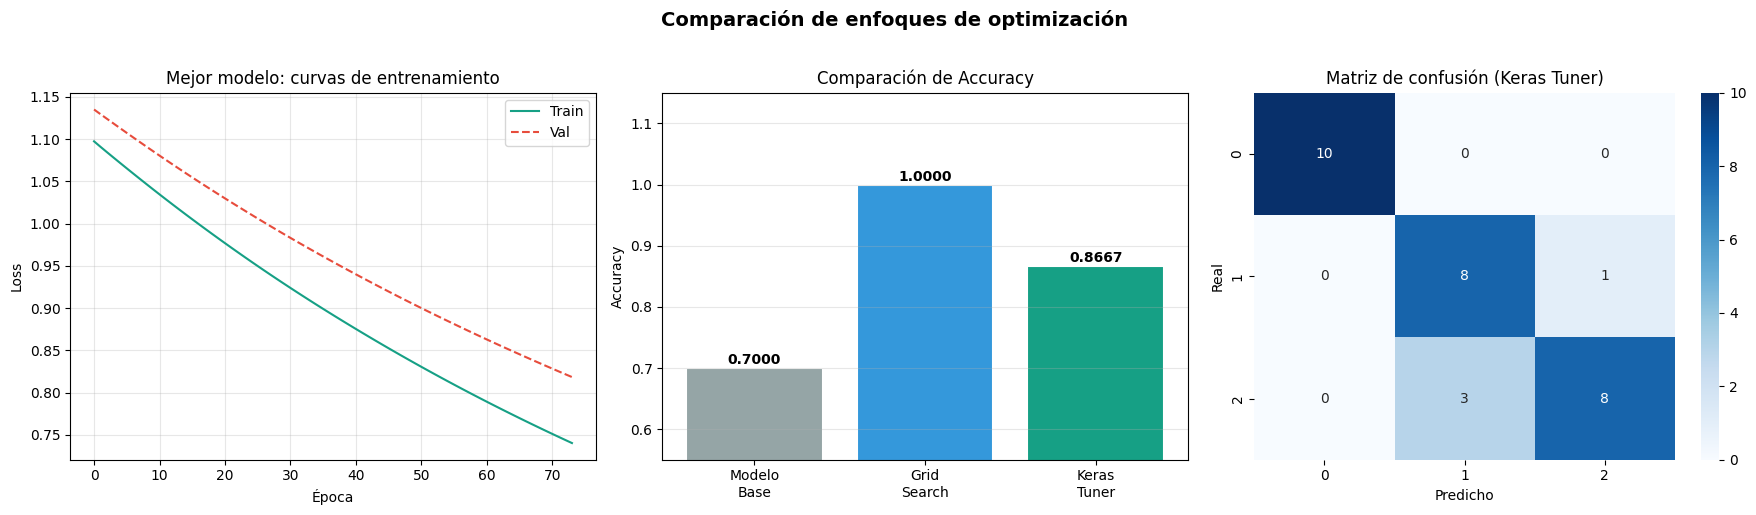

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Curvas de loss del mejor modelo
axes[0].plot(history_best.history['loss'], label='Train', color='#16a085')
axes[0].plot(history_best.history['val_loss'], label='Val', color='#e74c3c', linestyle='--')
axes[0].set_title('Mejor modelo: curvas de entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Comparación visual
nombres = ['Modelo\nBase', 'Grid\nSearch', 'Keras\nTuner']
valores = [base_val, gs_val, kt_val]
colores_bar = ['#95a5a6', '#3498db', '#16a085']
bars = axes[1].bar(nombres, valores, color=colores_bar, edgecolor='white', linewidth=1.5)
y_range = max(valores) - min(valores)
axes[1].set_ylim(min(valores) - y_range*0.5, max(valores) + y_range*0.5)
axes[1].set_title(f'Comparación de {metric_display}')
axes[1].set_ylabel(metric_display)
for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + y_range*0.02,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

# Predicho vs real (regresión) o residuos
if PROBLEM_TYPE == 'regression':
    mn, mx = y_test.min(), y_test.max()
    axes[2].scatter(y_test, y_pred_best, alpha=0.35, color='#16a085', s=15)
    axes[2].plot([mn,mx],[mn,mx], 'r--', lw=2, label='Predicción perfecta')
    axes[2].set_title(f'Keras Tuner: R²={kt_val:.4f}')
    axes[2].set_xlabel('Real')
    axes[2].set_ylabel('Predicho')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
else:
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred_final)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2])
    axes[2].set_title('Matriz de confusión (Keras Tuner)')
    axes[2].set_ylabel('Real')
    axes[2].set_xlabel('Predicho')

plt.suptitle('Comparación de enfoques de optimización', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📝 Análisis de la comparación — completar

1. **¿Cuánto mejoró cada técnica respecto al modelo base?**

   | Enfoque | Métrica | Mejora vs base |
   |---|---|---|
   | Modelo base | *(pegar)* | — |
   | Grid Search | *(pegar)* | *(calcular)* |
   | Keras Tuner | *(pegar)* | *(calcular)* |

2. **¿La mejora de Keras Tuner sobre Grid Search justificó el tiempo extra de cómputo?**
   > *Escribir aquí*

3. **¿Cuáles fueron los hiperparámetros más influyentes?** (learning rate, número de capas, dropout...)
   > *Escribir aquí*

4. **¿Qué hiperparámetros agregarías al espacio de búsqueda si tuvieras más tiempo?**
   > *Escribir aquí*

---
## Paso 9 — Guardado del mejor modelo

**¿Qué hace este paso?**  
Guardamos el modelo optimizado para reutilizarlo sin reentrenar.

In [20]:
nombre_archivo = f'mejor_modelo_{TARGET_COL}.keras'
best_model.save(nombre_archivo)
print(f'✅ Modelo guardado como: {nombre_archivo}')
print(f'   Para cargar: modelo = keras.models.load_model("{nombre_archivo}")')

# Resumen final
mejora_total = kt_val - base_val
print(f'\n📊 Resumen final:')
print(f'   {metric_display} modelo base:       {base_val:.4f}')
print(f'   {metric_display} Keras Tuner:        {kt_val:.4f}')
print(f'   Mejora total:                  {mejora_total:+.4f}')

✅ Modelo guardado como: mejor_modelo_target.keras
   Para cargar: modelo = keras.models.load_model("mejor_modelo_target.keras")

📊 Resumen final:
   Accuracy modelo base:       0.7000
   Accuracy Keras Tuner:        0.8667
   Mejora total:                  +0.1667


---
## Paso 10 — Conclusiones

### 📝 Conclusiones finales — completar

1. **¿Qué aprendiste sobre el proceso de optimización de hiperparámetros?**
   > Aprendí que el rendimiento de una red neuronal no depende únicamente de agregar más capas o neuronas a ciegas, sino de encontrar el equilibrio justo entre la arquitectura, la tasa de aprendizaje (learning rate) y técnicas de regularización como el Dropout.

2. **¿Cuál es la diferencia conceptual entre Grid Search y Bayesian Optimization?** Explicarlo con tus palabras.
   > La diferencia principal está en la "inteligencia" del método. Grid Search es un enfoque de fuerza bruta: prueba absolutamente todas las combinaciones predefinidas en una grilla de forma ciega, sin importar si los resultados anteriores fueron pésimos o excelentes. En cambio, Bayesian Optimization (el que usa Keras Tuner) es una estrategia secuencial e inteligente: analiza los resultados de los intentos (trials) anteriores y calcula estadísticamente dónde hay más probabilidades de encontrar una mejor combinación, dirigiendo la búsqueda hacia las zonas más prometedoras del espacio de hiperparámetros y ahorrando tiempo de cómputo.

3. **¿En qué tipo de proyecto real sería más valioso dedicar tiempo a optimizar hiperparámetros?**
   > Sería sumamente valioso en proyectos donde los datos sean masivos, complejos o altamente ruidosos (como visión por computadora, procesamiento de lenguaje natural o sistemas de recomendación en producción), y donde mejorar incluso un pequeño 1% o 2% en la métrica final (como el Accuracy o el F1-Score) se traduzca en un impacto crítico, ya sea económico, de seguridad o de experiencia de usuario. También es vital cuando se despliegan modelos en dispositivos con recursos limitados (Mobile/Edge IoT), ya que la optimización ayuda a encontrar redes más chicas y veloces sin perder precisión.

4. **¿Encontraste alguna configuración que empeoró el resultado?** ¿Por qué creés que pasó?
   > Sí, en la grilla manual y en algunos trials de Keras Tuner se pudo observar que configuraciones con un Learning Rate demasiado alto (0.01) o arquitecturas excesivamente grandes y profundas empeoraban el desempeño. En el caso del learning rate alto, el optimizador avanza a pasos tan grandes que "rebota" y no logra converger en el mínimo de la función de pérdida. Con respecto a las redes muy grandes para un dataset chico como Iris, el modelo memoriza el ruido de los datos de entrenamiento provocando overfitting (sobreajuste), lo que degrada drásticamente el Accuracy en el conjunto de testeo.

5. **¿Qué harías diferente si tuvieras un dataset 10 veces más grande?**
   > Si el dataset fuera 10 veces más grande, cambiaría la estrategia para cuidar los tiempos de cómputo, por ejemplo, en lugar de usar Grid Search (que se volvería prohibitivo), me inclinaría directamente por Random Search para un filtrado rápido, o mantendría Keras Tuner pero limitando estrictamente el número de épocas por intento mediante un callback de Early Stopping más agresivo.